# Homework 04: Building CNNs for Image Classification

### Due: September 27th at 11:59pm (with 2-hour + 1 minute grace period) and worth 85 points

In this assignment, you will take your first steps into designing and training convolutional neural networks (CNNs) for image classification. Starting from a simple baseline, you will experiment with modifications that reflect the kinds of design choices practitioners face every day. Along the way, you’ll see how architecture, hyperparameters, normalization, pooling strategies, and learning rate schedules can each shape a model’s performance.

The problems are organized to build on each other:

1. **Hyperparameters:** Begin with a baseline CNN and try variations in learning rate, layer width, depth, and dropout.
2. **Batch Normalization:** Add normalization after convolutional layers to stabilize training and speed convergence.
3. **Global Average Pooling:** Replace the flatten-and-dense head with a modern pooling layer, reducing parameters and improving generalization.
4. **ReduceLROnPlateau:** Explore a widely used learning rate scheduler that adapts when validation progress slows.
5. **Very Deep CNN:** Finally, run a VGG-16–style model to observe how deeper networks behave compared to smaller ones.

By the end of this homework, you will have hands-on experience with both classical and modern CNN design strategies, a sense of how different components affect learning, and a toolkit of techniques that will serve you in future image processing projects. 

There are 10 graded questions, worth 8 points each, with 5 points free if you complete all of the graded questions in the homework. 


## 1. Setup and Data Loading


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os,time,random,kagglehub

import tensorflow as tf
from tensorflow.keras import layers, Input, models, callbacks, regularizers,initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.optimizers import Adam,AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.layers import Dense,Input,Dropout,Flatten,MaxPooling2D,Conv2D,SeparableConv2D,GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization

from sklearn.model_selection import train_test_split

# utility code

# -------------------------
# Reproducibility settings
# -------------------------

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

I0000 00:00:1790697683.487199    2255 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Testing and training sets already defined, accessed here as global variables

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs        = 500,
                   lr_schedule   = 1e-3,
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.0001,
                   callbacks     = [],
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] if use_early_stopping else []) + callbacks

    start = time.time()

    # Fit on tf.data datasets (already batched)
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Determine best validation accuracy
    if use_early_stopping and hasattr(early_stop, "best_epoch") and early_stop.best_epoch is not None:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = int(np.argmax(history.history['val_accuracy']))
        best_acc   = history.history['val_accuracy'][best_epoch]

    plot_learning_curves(history, title=title)

    # Evaluate on tf.data test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
import os
import numpy as np
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 in [0,1]
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE    = (150, 150)
INPUT_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE  = 32
VAL_FRAC    = 0.2
SEED        = random_seed  # use your existing seed

# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# 2) Stratified deterministic split of *indices* (no images loaded)
train_idx, val_idx = stratified_split_indices(train_labels, val_frac=VAL_FRAC, seed=SEED)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]
files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets (lazy image loading)
train_ds = make_image_dataset(files_train, y_train, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=True, seed=SEED,
                              cache_to_disk=None)  

val_ds   = make_image_dataset(files_val, y_val, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=False,
                              cache_to_disk=None)  

# 5) Test set: keep same class mapping as train
test_files, test_labels, _ = list_files_and_labels(test_dir, class_names=class_names)
test_ds = make_image_dataset(test_files, test_labels, img_size=IMG_SIZE,
                             batch_size=BATCH_SIZE, shuffle=False,
                             cache_to_disk=None)




I0000 00:00:1790697695.156655    2255 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6071 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


In [7]:
# # Show 25 sample images

# plt.figure(figsize=(12, 12))

# # Take one batch from the dataset
# images, labels = next(iter(train_ds))

# for i in range(25):
#     ax = plt.subplot(5, 5, i + 1)
#     plt.imshow(images[i].numpy())
#     plt.title(class_names[int(labels[i])], fontsize=9)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()


### Prelude: Baseline CNN (reference model)

This is our **reference** network: two Conv→Pool blocks with channels **32 → 64**, followed by a **single hidden head** `Dense(64)`. We use **He** initialization for ReLU activations and include an **optional `Dropout(0.5)`** to illustrate regularization—comment it out to gauge its impact (ha, not really optional!). 

Use this model as a stable yardstick while you run **ablations**: change **one knob at a time** (e.g., widen/deepen the conv blocks, adjust dropout rate, add batch norm, tweak the LR schedule) and compare results back to this baseline. Focus on **training vs. validation curves**, the **generalization gap**, and how dropout affects **val loss/accuracy** and how long it takes for Early Stopping to kick in. 


> **Note:** On rare runs, training may become numerically unstable and produce `NaN` loss values. If this occurs, rerun the model. If the problem persists, restart the runtime and run the notebook again from the beginning.


Baseline Model



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790697698.913335    2327 service.cc:153] XLA service 0x7305040343f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790697698.913371    2327 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1790697698.942494    2327 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790697699.138154    2327 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1790697699.182958    2327 dot_merger.cc:4

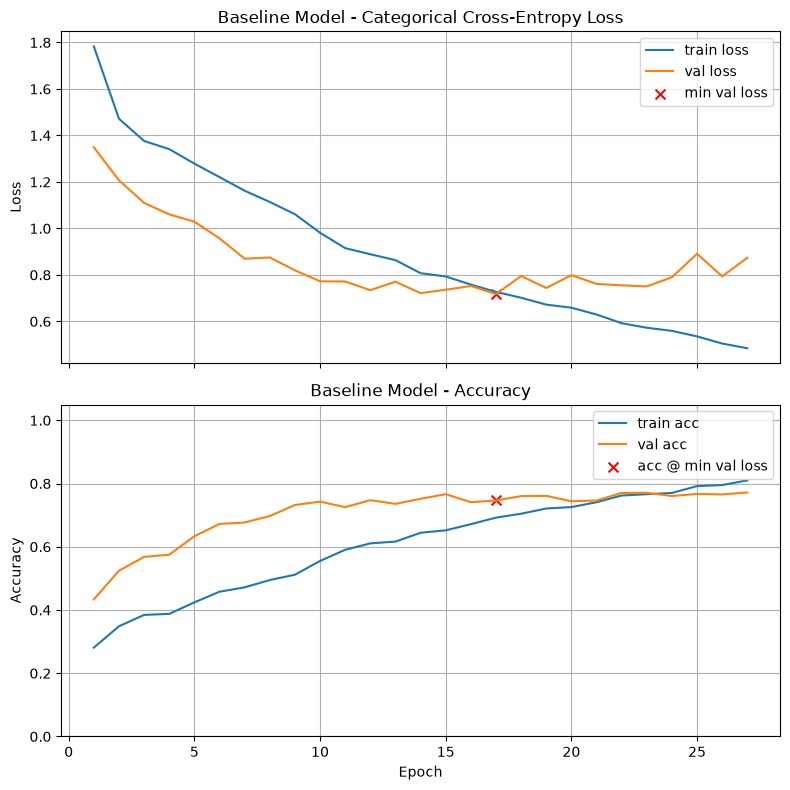

Final Training Loss:            0.4846
Final Training Accuracy:        0.8101
Final Validation Loss:          0.8738
Final Validation Accuracy:      0.7718
Minimum Validation Loss:        0.7174 (Epoch 17)
Validation Accuracy @ Min Loss: 0.7464

Test Loss: 0.7532
Test Accuracy: 0.7427

Validation-Test Gap (accuracy): 0.003767

Execution Time: 00:02:42


In [8]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model")


In [11]:
all_runtime_start = time.time()

## Problem One: Exploring Basic Hyperparameters

**Task:**
Copy the baseline CNN model into the next cell and experiment with basic hyperparameter changes. Your goal is to see whether small tweaks can improve validation accuracy (and hopefully speed up convergence or produce smoother training curves). You must **pick 3 of the following tweaks** and investigate their effect:

**Tweaks to Try:**

1. Adjust the learning rate (default for Adam is `1e-3`).
2. Change the width of the `Conv2D` layers (e.g., 64 → 128).
3. Add an extra `Conv2D` layer (e.g., stack 32 → 64 → 128).
4. Change the width of the `Dense(64 ...)` layer. 
5. Add L2 regularization to the `Dense(64 ...)` layer (see the head of the network in Problem 5 for inspiration).  
6. Modify the dropout rate.
   
Observe the effect of each of your 3 choices in isolation and answer the graded questions.

**Optional:**
Combine two or more changes to see if they work together to improve results (example: try L2 regularization and reduced dropout in the head, as in Problem 5). 


**Pro Tip:** Give each experiment a descriptive title, such as "Problem 1 -- Tweak 1 -- lr: 0.0005" to keep track of your experiments (see last cell in the notebook).


baseline



I0000 00:00:1790711742.511929    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97543__.31
I0000 00:00:1790711749.354802    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97543__.31


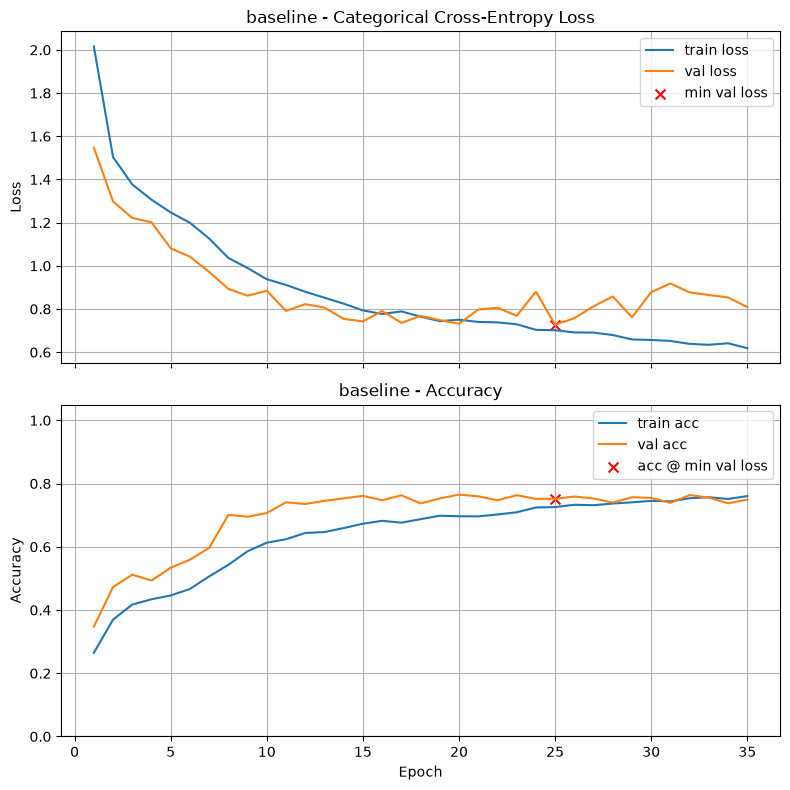

Final Training Loss:            0.6184
Final Training Accuracy:        0.7603
Final Validation Loss:          0.8091
Final Validation Accuracy:      0.7493
Minimum Validation Loss:        0.7272 (Epoch 25)
Validation Accuracy @ Min Loss: 0.7518

Test Loss: 0.8494
Test Accuracy: 0.7403

Validation-Test Gap (accuracy): 0.011450

Execution Time: 00:03:23
Problem 1 -- baseline:  val_acc = 0.7649785876274109

p1--tweak2--conv[64->128]



I0000 00:00:1790711946.285917    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_162485__.31
E0000 00:00:1790711947.617670    2325 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790711959.815174    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_162485__.31
E0000 00:00:1790711961.084295    2325 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


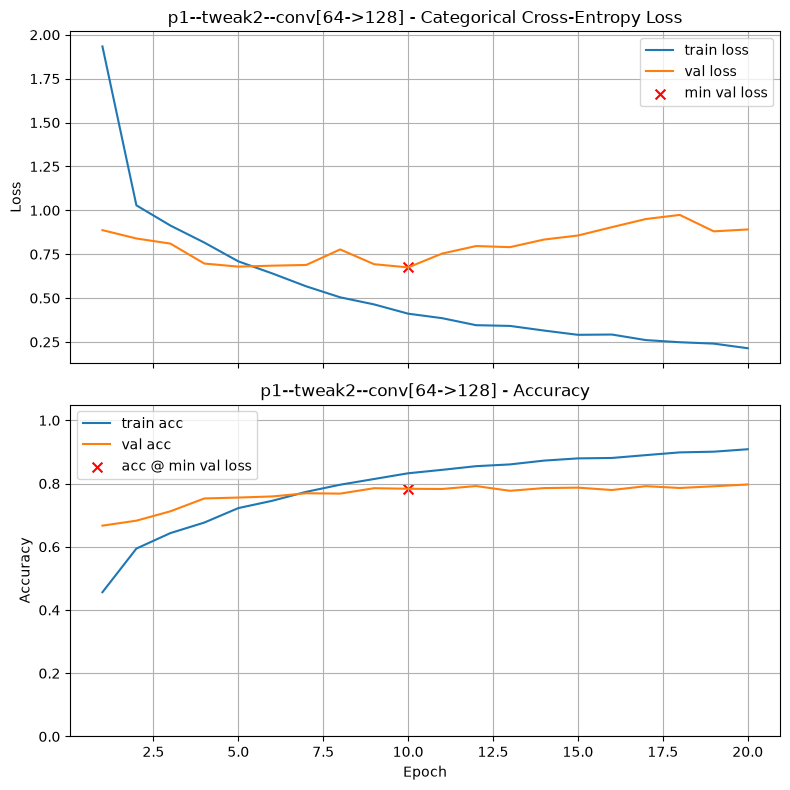

Final Training Loss:            0.2145
Final Training Accuracy:        0.9085
Final Validation Loss:          0.8910
Final Validation Accuracy:      0.7971
Minimum Validation Loss:        0.6749 (Epoch 10)
Validation Accuracy @ Min Loss: 0.7835

Test Loss: 0.6847
Test Accuracy: 0.7770

Validation-Test Gap (accuracy): 0.006524

Execution Time: 00:03:36
Problem 1 -- p1--tweak2--conv[64->128]:  val_acc = 0.797075629234314

p1--tweak3--conv[64->128]



I0000 00:00:1790712163.530997    2326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_200832__.40
I0000 00:00:1790712172.290959    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_200832__.40


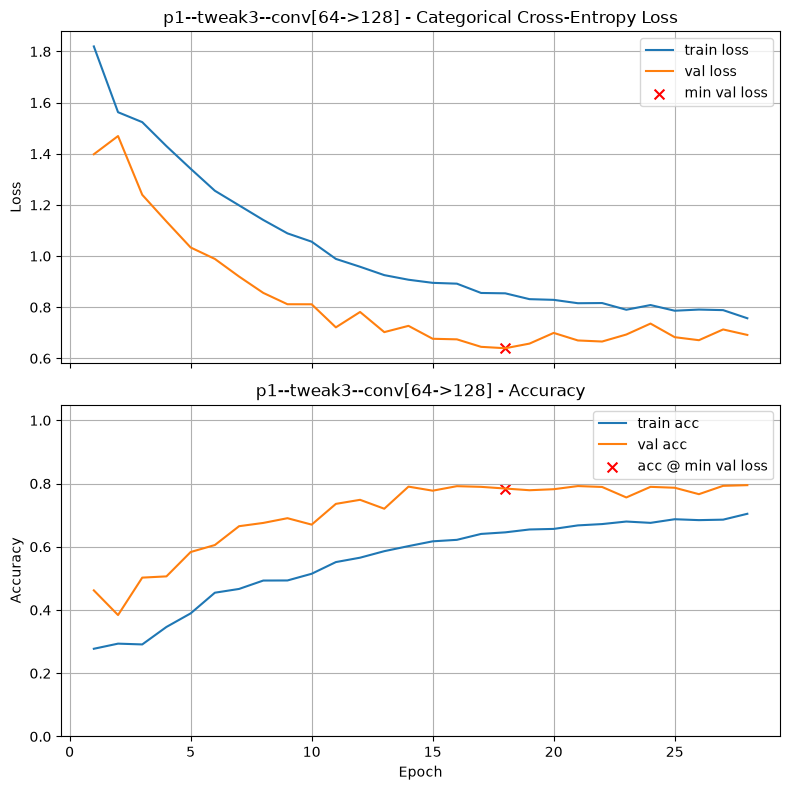

Final Training Loss:            0.7568
Final Training Accuracy:        0.7044
Final Validation Loss:          0.6917
Final Validation Accuracy:      0.7949
Minimum Validation Loss:        0.6397 (Epoch 18)
Validation Accuracy @ Min Loss: 0.7842

Test Loss: 0.6849
Test Accuracy: 0.7843

Validation-Test Gap (accuracy): 0.000097

Execution Time: 00:03:12
Problem 1 -- p1--tweak3--conv[64->128]:  val_acc = 0.7949358224868774

p1--tweak4--dense(32)



I0000 00:00:1790712355.659699    2323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_253371__.31
I0000 00:00:1790712362.281880    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_253371__.31


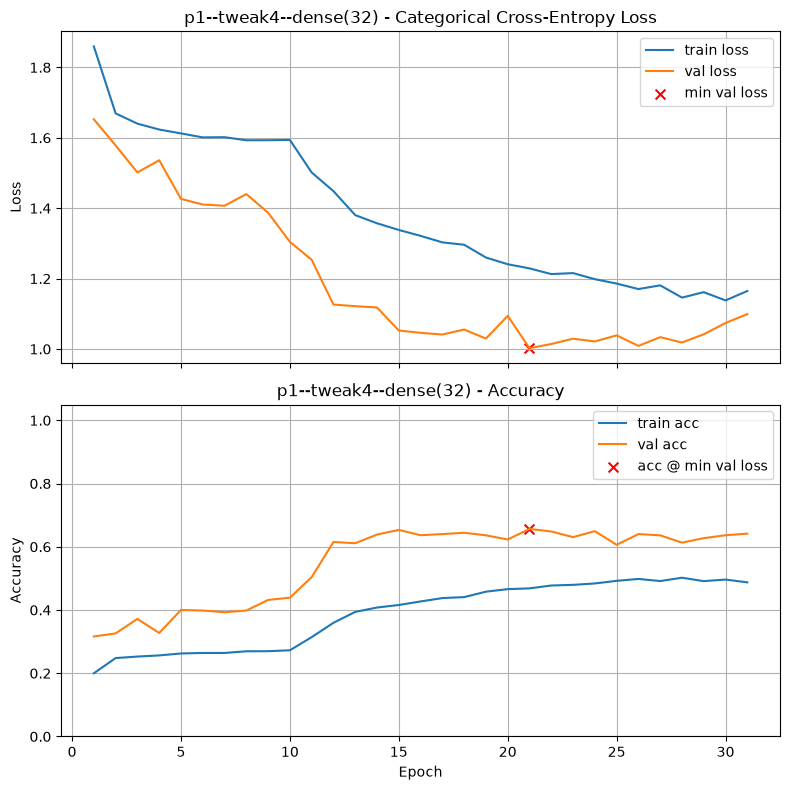

Final Training Loss:            1.1648
Final Training Accuracy:        0.4875
Final Validation Loss:          1.0992
Final Validation Accuracy:      0.6416
Minimum Validation Loss:        1.0022 (Epoch 21)
Validation Accuracy @ Min Loss: 0.6566

Test Loss: 1.0243
Test Accuracy: 0.6387

Validation-Test Gap (accuracy): 0.017895

Execution Time: 00:02:54
Problem 1 -- p1--tweak4--dense(32):  val_acc = 0.6565620303153992

p1--tweak5--l2_reg:1e-4



I0000 00:00:1790712529.838557    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_311271__.33
I0000 00:00:1790712536.556950    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_311271__.33


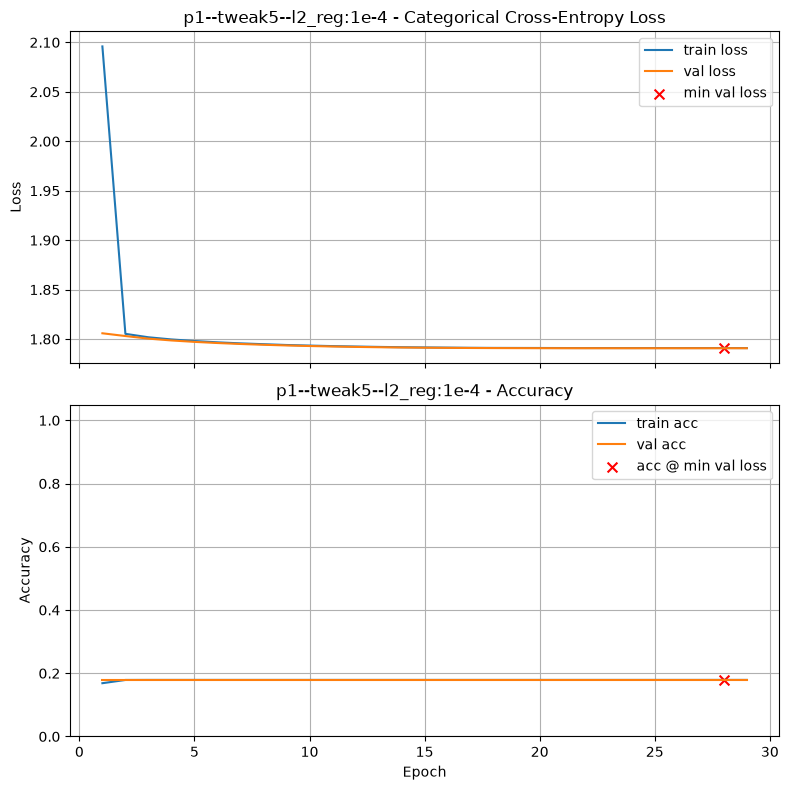

Final Training Loss:            1.7909
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7908
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7908 (Epoch 28)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7903
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:02:49
Problem 1 -- p1--tweak5--l2_reg:1e-4:  val_acc = 0.17902995645999908

p1--tweak6--do:0.3



I0000 00:00:1790712699.202948    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_365563__.31
I0000 00:00:1790712705.636511    2323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_365563__.31


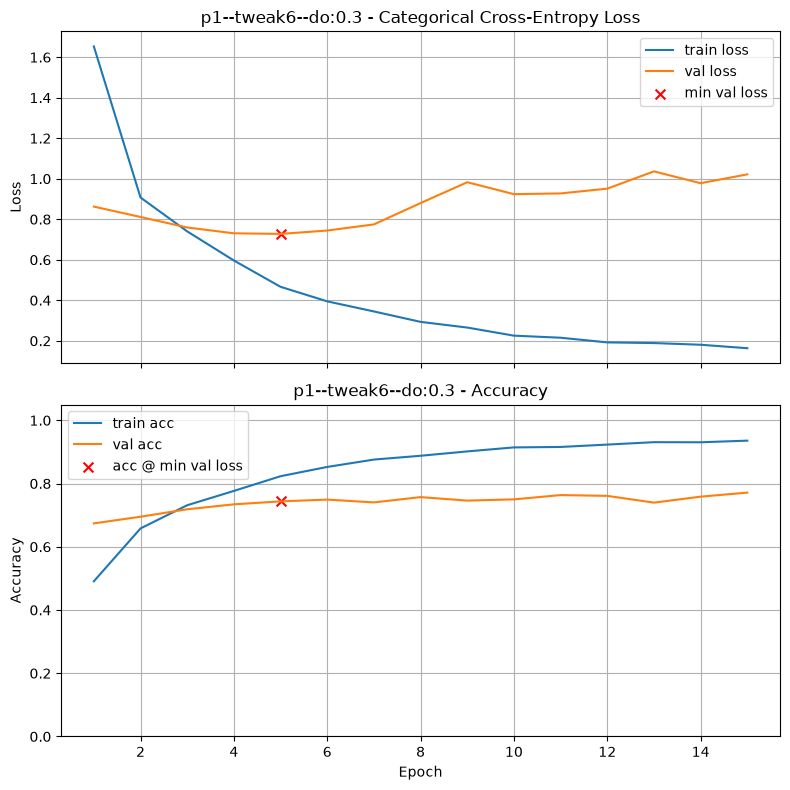

Final Training Loss:            0.1634
Final Training Accuracy:        0.9357
Final Validation Loss:          1.0218
Final Validation Accuracy:      0.7714
Minimum Validation Loss:        0.7277 (Epoch 5)
Validation Accuracy @ Min Loss: 0.7436

Test Loss: 0.7918
Test Accuracy: 0.7487

Validation-Test Gap (accuracy): 0.005086

Execution Time: 00:01:28
Problem 1 -- p1--tweak6--do:0.3:  val_acc = 0.7713980078697205
Overall winner: p1--tweak2--conv[64->128] with val_acc = 0.7714


In [12]:
# Your code here, add additional cells if you wish

def baseline_model_w_options(
        dense_w=64, 
        dropout=0.5, 
        l2_reg=None, 
        layer_structure = [32, 64]
        ):
    
    he = initializers.HeNormal()       
    reg64 = regularizers.L2(l2_reg) if l2_reg else None                         

    
    layer_list = [Input(shape=INPUT_SHAPE)]
    for i in layer_structure:
        layer_list += [
            Conv2D(i, 
                   (3,3), 
                   activation="relu",    
                   kernel_initializer=he,  
                   padding="same"),
            MaxPooling2D(2),
        ]

    layer_list += [
        Flatten(),
        Dense(dense_w,          
              activation="relu",    
              kernel_initializer=he,
              kernel_regularizer=reg64),
        Dropout(dropout),
        Dense(num_classes, activation="softmax")
    ]

    model = models.Sequential(layer_list)

    return model


#### ----------------------------------------------------- ####

p1_experiment = {
    'baseline':                 dict(),
    # 'p1--tweak1--lr:0.0005':    dict(lr= 5e-4),
    'p1--tweak2--conv[64->128]':dict(layer_structure= [64,128]),
    'p1--tweak3--conv[64->128]':dict(layer_structure= [32,64,128]),
    'p1--tweak4--dense(32)':    dict(dense_w= 32),
    'p1--tweak5--l2_reg:1e-4':    dict(l2_reg = 1e-4),
    'p1--tweak6--do:0.3':    dict(dropout=0.3),

}


#### ----------------------------------------------------- ####

p1_histories = {}

for title, cfg in p1_experiment.items():
    model = baseline_model_w_options(**cfg)
    p1_histories[title] = train_and_test(
                model, 
                # epochs        = 500,
                # lr_schedule   = 1e-3,
                # optimizer     = "Adam",
                title         = title,
                # use_early_stopping = True,
                # patience      = 10,
                # min_delta     = 0.001,
                # callbacks     = [],
                # verbose       = 0,
                return_history = True
                )
    p1_acc = max(p1_histories[title].history['val_accuracy'])
    print(f'Problem 1 -- {title}:  val_acc = {p1_acc}')

p1_best_acc = max(p1_histories[title].history['val_accuracy'])
p1_best_tweak =  max(p1_histories, key=lambda t: max(p1_histories[t].history['val_accuracy']))
print(f'Overall winner: {p1_best_tweak} with val_acc = {p1_best_acc:.4f}')

### Graded Questions

In [43]:
# Set a1a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 3             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [44]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 3


In [15]:
# Set a1b to the validation accuracy found by the choice specified in Question a1a. 

a1b = p1_best_acc             # Replace 0.0 with your answer

In [16]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7714


## Problem Two: Adding Batch Normalization

**Task:**
Take your best model from Problem One and add a `BatchNormalization()` layer immediately after each `Conv2D` layer. Batch normalization helps stabilize training and can improve convergence. 

**Next Steps:**

* Train the model with batch normalization included after each `Conv2D` layer. 
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare the results to your earlier experiments and answer the graded questions.

**Optional:**
Try more than one hyperparameter change alongside batch normalization and see how they interact.




p2 Model - batch normalization



I0000 00:00:1790712788.576264    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_395537__.41
I0000 00:00:1790712797.264234    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_395537__.41


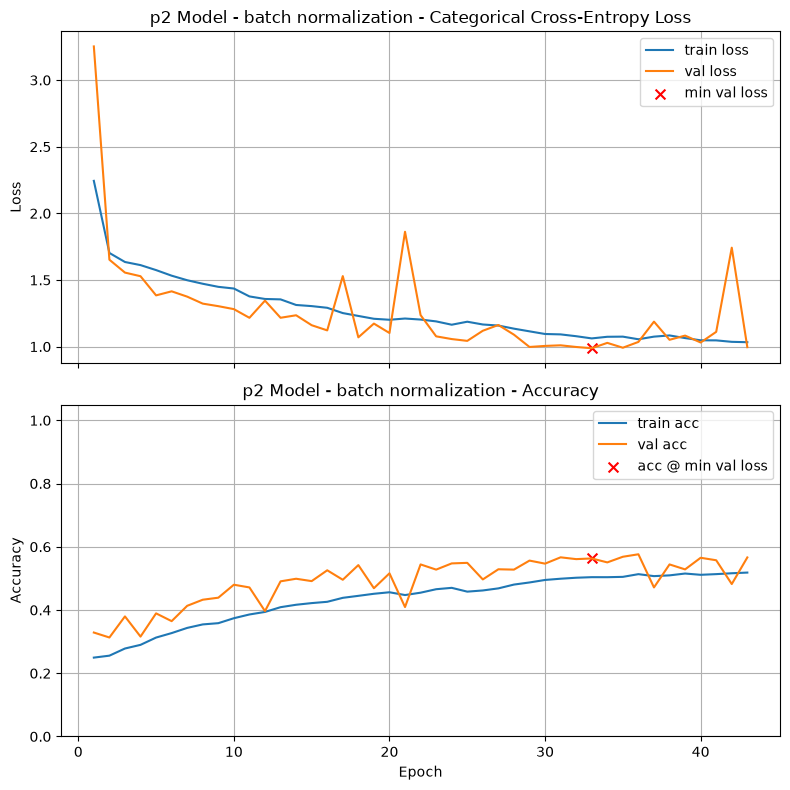

Final Training Loss:            1.0333
Final Training Accuracy:        0.5184
Final Validation Loss:          0.9961
Final Validation Accuracy:      0.5663
Minimum Validation Loss:        0.9881 (Epoch 33)
Validation Accuracy @ Min Loss: 0.5631

Test Loss: 1.0507
Test Accuracy: 0.5370

Validation-Test Gap (accuracy): 0.026124

Execution Time: 00:04:41


In [17]:
# Your code here, add additional cells if you wish

he = initializers.HeNormal()                                # best initializer for relu

p2_model= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(p2_model,title=f"p2 Model - batch normalization")


p2 Model - batch normalization + tweak 3



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790731033.514470    2323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2246202__.41
I0000 00:00:1790731041.793453    2326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2246202__.41


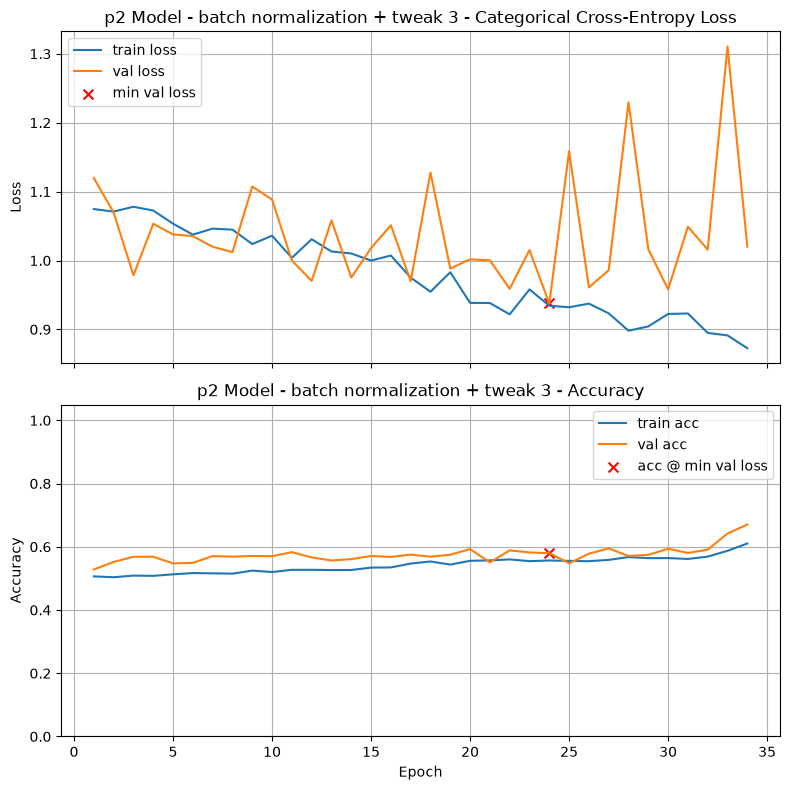

Final Training Loss:            0.8727
Final Training Accuracy:        0.6103
Final Validation Loss:          1.0202
Final Validation Accuracy:      0.6705
Minimum Validation Loss:        0.9377 (Epoch 24)
Validation Accuracy @ Min Loss: 0.5799

Test Loss: 0.9835
Test Accuracy: 0.5557

Validation-Test Gap (accuracy): 0.024219

Execution Time: 00:03:50


In [45]:

p2_model2= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(p2_model,title=f"p2 Model - batch normalization + tweak 3")

### Graded Questions

In [48]:
# Set a2a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 3             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [49]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 


a2a = 3


In [50]:
# Set a2b to the validation accuracy found by the choice specified in Question a2a (your best model for this problem) 

a2b = 0.5799             # Replace 0.0 with your answer

In [51]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.5799


## Problem Three: Global Average Pooling

As we saw in this week's Coding Video, 
**Global Average Pooling** is a simple layer that replaces the `Flatten → Dense` part of a CNN (please review that part of the Coding Notebook, which contains a description of this important technique). 

In practice, swapping `Flatten` for `GlobalAveragePooling2D` often improves stability and validation performance — definitely worth considering!


**Task:**
Modify your best model from Problems 1 & 2 to use a `GlobalAveragePooling2D()` layer instead of a flatten-and-dense block. 

**Next Steps:**

* Replace the sequence between the last `Conv2D` and output layers, for example:

     
          MaxPooling2D((2, 2)),
          Flatten(),
          Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
          Dropout(0.5),   

  with a single `GlobalAveragePooling2D()` layer.
* Train the model and observe how performance and training curves change.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare results and answer the graded questions.

**Optional:**
Experiment with `GlobalMaxPooling2D()` as an alternative and compare its behavior to `GlobalAveragePooling2D()`.




p3-baseline



I0000 00:00:1790713069.898176    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_475151__.31
I0000 00:00:1790713076.356752    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_475151__.31


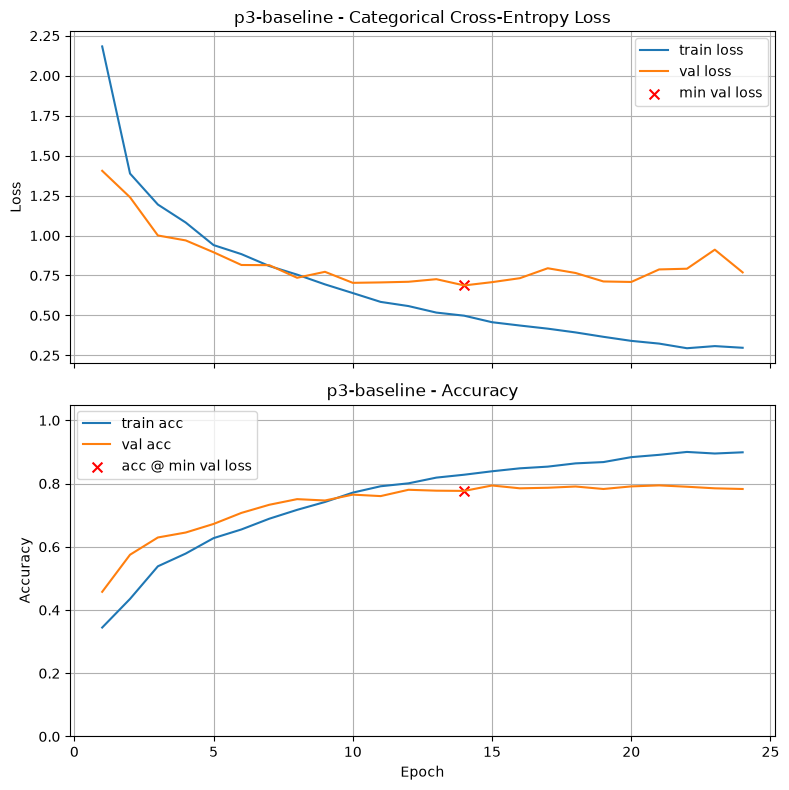

Final Training Loss:            0.2979
Final Training Accuracy:        0.8988
Final Validation Loss:          0.7695
Final Validation Accuracy:      0.7828
Minimum Validation Loss:        0.6879 (Epoch 14)
Validation Accuracy @ Min Loss: 0.7767

Test Loss: 0.7285
Test Accuracy: 0.7807

Validation-Test Gap (accuracy): 0.003919

Execution Time: 00:02:18
Problem 1 -- p3-baseline:  val_acc = 0.7942225337028503

p3--tweak2--conv[64->128]



I0000 00:00:1790713208.012563    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_520389__.31
I0000 00:00:1790713218.985835    2323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_520389__.31


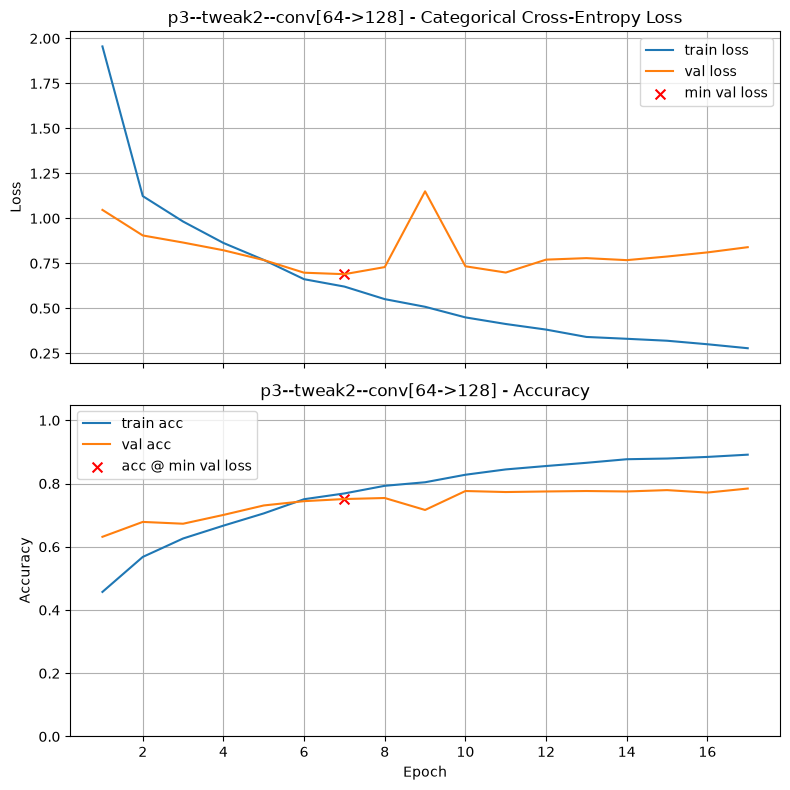

Final Training Loss:            0.2779
Final Training Accuracy:        0.8914
Final Validation Loss:          0.8396
Final Validation Accuracy:      0.7842
Minimum Validation Loss:        0.6895 (Epoch 7)
Validation Accuracy @ Min Loss: 0.7511

Test Loss: 0.7426
Test Accuracy: 0.7443

Validation-Test Gap (accuracy): 0.006737

Execution Time: 00:03:00
Problem 1 -- p3--tweak2--conv[64->128]:  val_acc = 0.7842367887496948
Overall winner: p3-baseline with val_acc = 0.7842


In [22]:
# Your code here, add additional cells if you wish

def p3_model(
        # dense_w=64, 
        # dropout=0.5, 
        # l2_reg=None, 
        layer_structure = [32, 64]
        ):
    
    # he = initializers.HeNormal()       
    # reg64 = regularizers.L2(l2_reg) if l2_reg else None                         

    
    layer_list = [Input(shape=INPUT_SHAPE)]
    for i in layer_structure:
        layer_list += [
            Conv2D(i, 
                   (3,3), 
                   activation="relu",    
                   kernel_initializer=he,  
                   padding="same"),
            MaxPooling2D(2),
        ]

    layer_list += [
        # Flatten(),
        # Dense(dense_w,          
        #       activation="relu",    
        #       kernel_initializer=he,
        #       kernel_regularizer=reg64),
        # Dropout(dropout),
        GlobalAveragePooling2D(),
        Dense(num_classes, activation="softmax")
    ]

    model = models.Sequential(layer_list)

    return model


#### ----------------------------------------------------- ####

p3_experiment = {
    'p3-baseline':                 dict(),
    # 'p1--tweak1--lr:0.0005':    dict(lr= 5e-4),
    'p3--tweak2--conv[64->128]':dict(layer_structure= [64,128]),
    # 'p1--tweak3--conv[64->128]':dict(layer_structure= [32,64,128]),
    # 'p1--tweak4--dense(32)':    dict(dense_w= 32),
    # 'p1--tweak5--l2_reg:1e-4':    dict(l2_reg = 1e-4),
    # 'p1--tweak6--do:0.3':    dict(dropout=0.3),

}


#### ----------------------------------------------------- ####

p3_histories = {}

for title, cfg in p3_experiment.items():
    model = baseline_model_w_options(**cfg)
    p3_histories[title] = train_and_test(
                model, 
                # epochs        = 500,
                # lr_schedule   = 1e-3,
                # optimizer     = "Adam",
                title         = title,
                # use_early_stopping = True,
                # patience      = 10,
                # min_delta     = 0.001,
                # callbacks     = [],
                # verbose       = 0,
                return_history = True
                )
    p3_acc = max(p3_histories[title].history['val_accuracy'])
    print(f'Problem 1 -- {title}:  val_acc = {p3_acc}')

p3_best_acc = max(p3_histories[title].history['val_accuracy'])
p3_best_tweak =  max(p3_histories, key=lambda t: max(p3_histories[t].history['val_accuracy']))
print(f'Overall winner: {p3_best_tweak} with val_acc = {p3_best_acc:.4f}')

### Graded Questions

In [46]:
# Set a3a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a3a = -1             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [47]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 


a3a = -1


In [25]:
# Set a3b to the validation accuracy found by the choice specified in Question a3a (your best model for this problem) 

a3b = p3_best_acc             # Replace 0.0 with your answer

In [26]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7842


## Problem Four: ReduceLROnPlateau

`ReduceLROnPlateau` is a widely used learning rate scheduling technique. It monitors a validation metric (usually `val_loss`) and reduces the learning rate when progress stalls, allowing the model to refine training at a smaller step size. This is one of the most useful scheduling tools (along with the essential Early Stopping) to have in your toolbox.

**Task:**
Augment your best model found so far in Problems 1 - 3 with the `ReduceLROnPlateau` callback during training.

**Next Steps:**

* Add the callback parameter to `train_and_test`:

  ```python
  callbacks=[reduce_lr]
  ```

* Start with **`factor=0.5`** (monitor `val_loss`, `patience=2–3`, `cooldown=1`, `min_lr=1e-5` for Adam).
* **Practical playbook:**

  * If plateau persists after one reduction → try **`factor=0.3`**, then **`0.2`**.
  * If a reduction hurts validation noticeably → try **`factor=0.7–0.8`** or increase **`patience`**.
  * Leave **`cooldown=1`** unless you see too-frequent drops.
* Experiment with **`patience` = 3, 5, 8** and **`min_delta` = `1e-4` vs `1e-3`** to gauge sensitivity.
* Choose the configuration with the best validation results—or note that ReduceLROnPlateau didn’t help (rare!). 
* Answer the graded questions.



In [27]:
# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',    # Quantity to be monitored.
#     factor=0.5,            # Factor by which the learning rate will be reduced.
#                            # new_lr = lr * factor
#     patience=3,            # Number of epochs with no improvement
#                            # after which learning rate will be reduced.
#     min_delta=1e-4,        # Threshold for measuring the new optimum,
#                            # to only focus on significant changes.
#     cooldown=1,            # Number of epochs to wait before resuming
#                            # normal operation after lr has been reduced.
#     min_lr=1e-5,           # Lower bound on the learning rate.
#     verbose=0,             # 0: quiet, 1: update messages.
# )

# # Your code here, add more cells as needed


p4-factor: 0.5



I0000 00:00:1790713388.274761    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_552732__.30
I0000 00:00:1790713394.251328    2325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_552732__.30


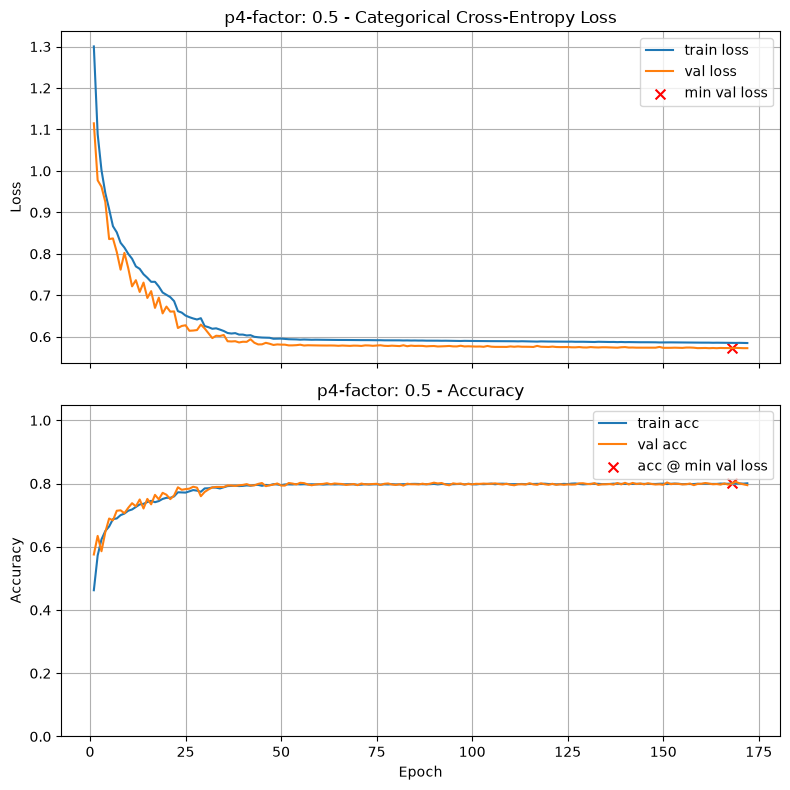

Final Training Loss:            0.5849
Final Training Accuracy:        0.8008
Final Validation Loss:          0.5725
Final Validation Accuracy:      0.7949
Minimum Validation Loss:        0.5723 (Epoch 168)
Validation Accuracy @ Min Loss: 0.8006

Test Loss: 0.6074
Test Accuracy: 0.7840

Validation-Test Gap (accuracy): 0.015572

Execution Time: 00:15:11

p4-factor: 0.3



I0000 00:00:1790714299.884617    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_863002__.30
I0000 00:00:1790714305.664316    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_863002__.30


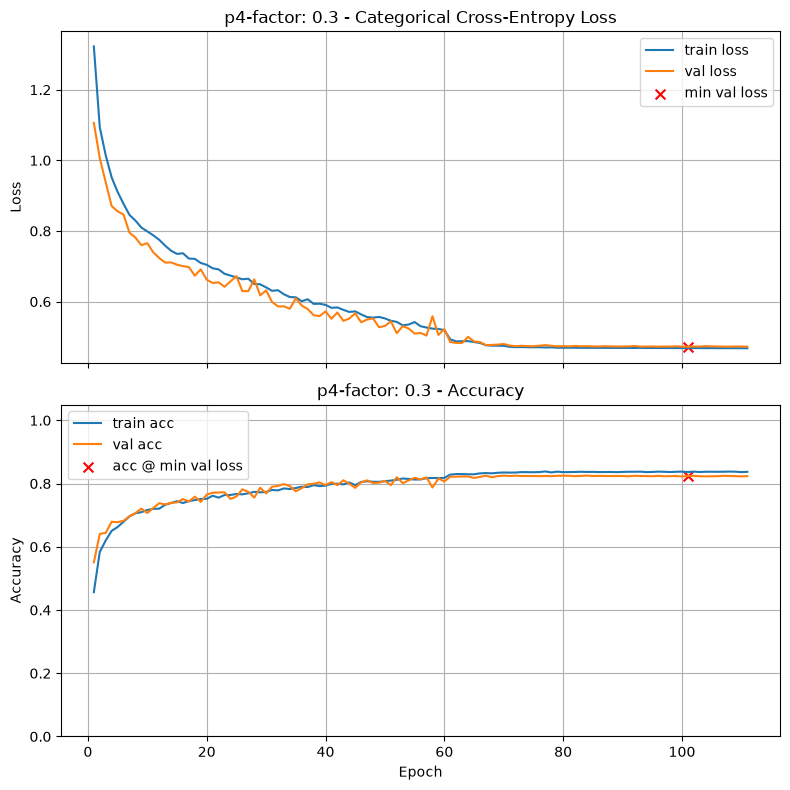

Final Training Loss:            0.4680
Final Training Accuracy:        0.8371
Final Validation Loss:          0.4726
Final Validation Accuracy:      0.8235
Minimum Validation Loss:        0.4721 (Epoch 101)
Validation Accuracy @ Min Loss: 0.8238

Test Loss: 0.4999
Test Accuracy: 0.8193

Validation-Test Gap (accuracy): 0.004490

Execution Time: 00:09:45

p4-factor: 0.2



I0000 00:00:1790714885.210728    2324 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1064066__.30
I0000 00:00:1790714891.033781    2323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1064066__.30


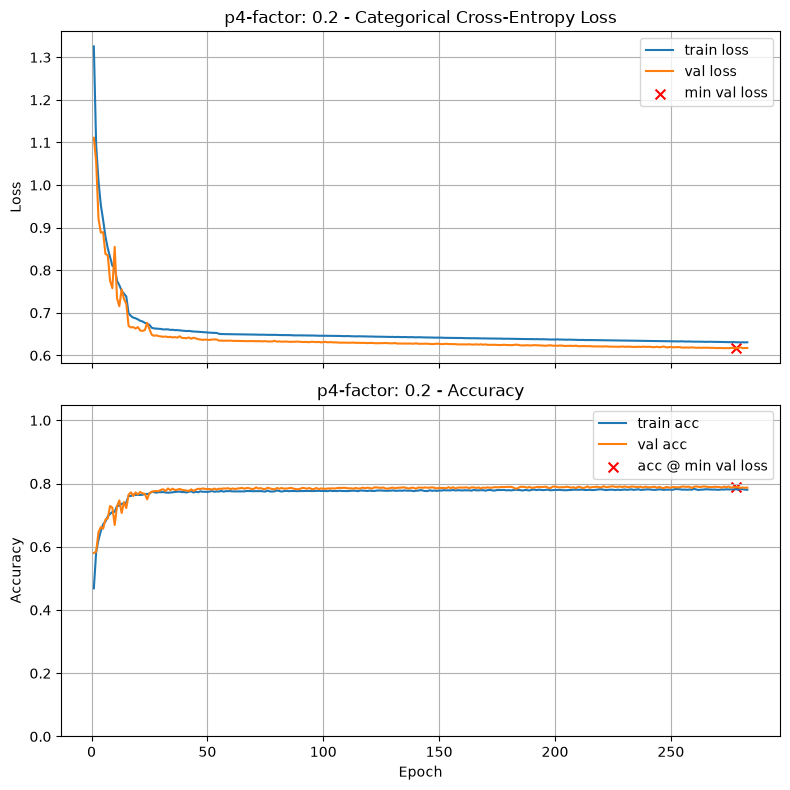

Final Training Loss:            0.6309
Final Training Accuracy:        0.7804
Final Validation Loss:          0.6175
Final Validation Accuracy:      0.7871
Minimum Validation Loss:        0.6169 (Epoch 278)
Validation Accuracy @ Min Loss: 0.7882

Test Loss: 0.6492
Test Accuracy: 0.7723

Validation-Test Gap (accuracy): 0.017966

Execution Time: 00:24:47

p4-patience: 3



I0000 00:00:1790716372.463844    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1573527__.30
I0000 00:00:1790716378.247488    2327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1573527__.30


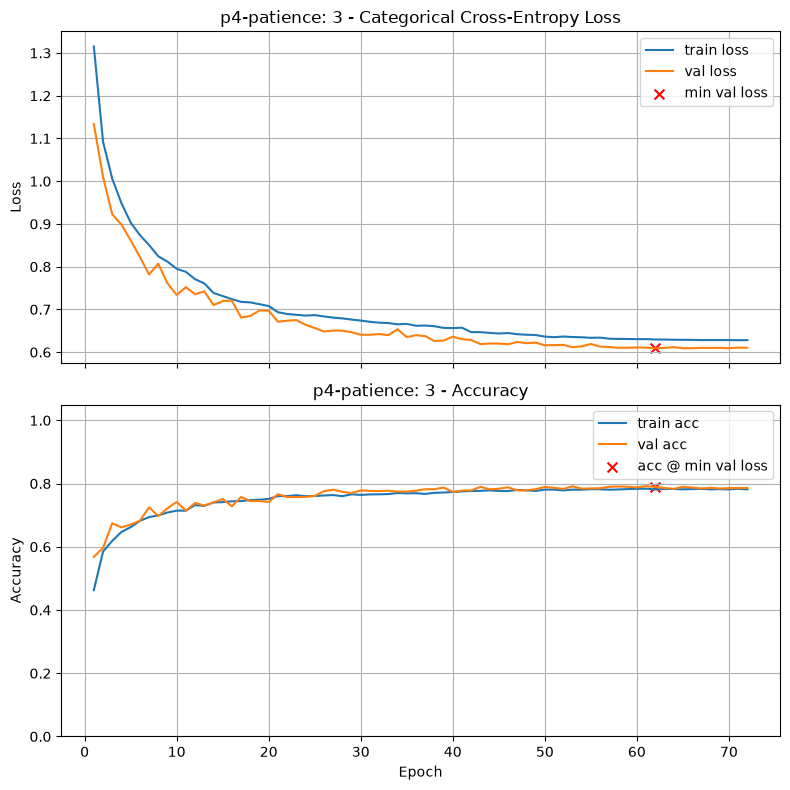

Final Training Loss:            0.6282
Final Training Accuracy:        0.7816
Final Validation Loss:          0.6102
Final Validation Accuracy:      0.7860
Minimum Validation Loss:        0.6092 (Epoch 62)
Validation Accuracy @ Min Loss: 0.7892

Test Loss: 0.6500
Test Accuracy: 0.7720

Validation-Test Gap (accuracy): 0.017230

Execution Time: 00:06:21

p4-patience: 5



I0000 00:00:1790716754.165948    2326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1704553__.30
I0000 00:00:1790716759.964230    2326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1704553__.30


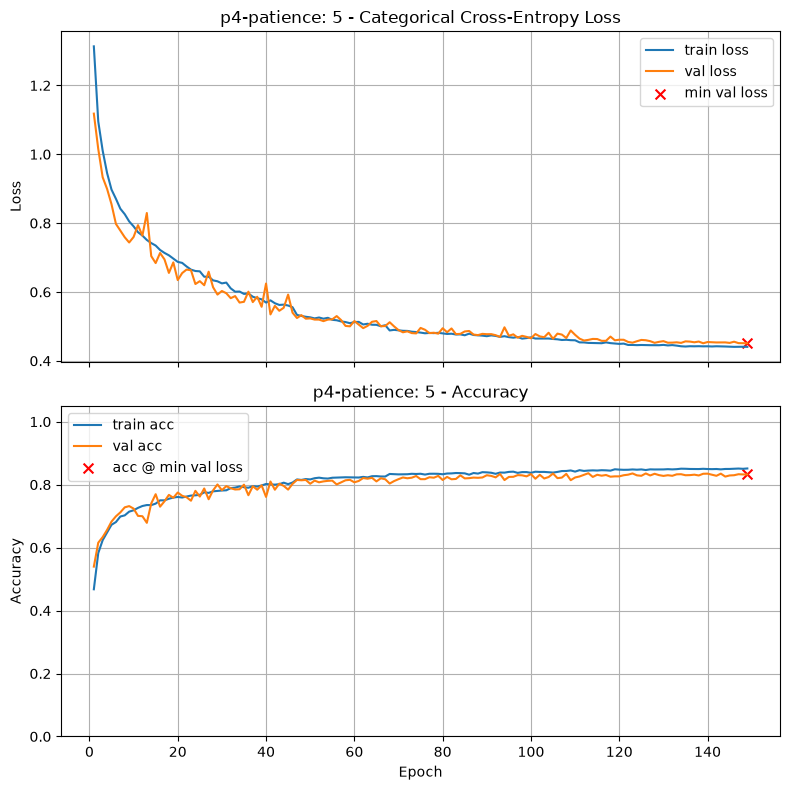

Final Training Loss:            0.4405
Final Training Accuracy:        0.8514
Final Validation Loss:          0.4510
Final Validation Accuracy:      0.8324
Minimum Validation Loss:        0.4510 (Epoch 149)
Validation Accuracy @ Min Loss: 0.8324

Test Loss: 0.4807
Test Accuracy: 0.8303

Validation-Test Gap (accuracy): 0.004189

Execution Time: 00:13:08


In [28]:
def reduce_lr(factor=0.5, patience=3, min_delta=1e-4):
    return ReduceLROnPlateau(
        monitor='val_loss',
        factor=factor,
        patience=patience,
        cooldown=1,
        min_delta=min_delta,
        min_lr=1e-5,
        verbose=0,
    )


factor_runs = {
    f'p4-factor: {f}': dict(factor=f)
    for f in [0.5, 0.3, 0.2]
}

patience_runs = {
    f'p4-patience: {p}': dict(patience=p)
    for p in [3, 5]
}

p4_record = []
for tweak, run in ('factor', factor_runs), ('patience', patience_runs):
    for title, cfg in run.items():
        p4_history = train_and_test(
            p3_model(),
            callbacks=[reduce_lr(**cfg)],
            title=title,
            return_history=True,
        )

        p4_acc = max(p4_history.history["val_accuracy"])
        p4_record.append({
            'config': tweak,
            'setting': title,
            'val_acc': p4_acc
        })




In [29]:
results

{'Baseline Model': (0.746433675289154, 17),
 'baseline': (0.7517831921577454, 25),
 'p1--tweak2--conv[64->128]': (0.7835235595703125, 10),
 'p1--tweak3--conv[64->128]': (0.7842367887496948, 18),
 'p1--tweak4--dense(32)': (0.6565620303153992, 21),
 'p1--tweak5--l2_reg:1e-4': (0.17902995645999908, 28),
 'p1--tweak6--do:0.3': (0.7435805797576904, 5),
 'p2 Model - batch normalization': (0.5631241202354431, 33),
 'p3-baseline': (0.7767475247383118, 14),
 'p3--tweak2--conv[64->128]': (0.7510699033737183, 7),
 'p4-factor: 0.5': (0.8006419539451599, 168),
 'p4-factor: 0.3': (0.823823094367981, 101),
 'p4-factor: 0.2': (0.7881597876548767, 278),
 'p4-patience: 3': (0.789229691028595, 62),
 'p4-patience: 5': (0.832382321357727, 149)}

### Graded Questions

In [52]:
# Set a4a to the factor parameter which gave the best validation accuracy at the point of minimum validation loss

a4a = 0.3            # Replace with your best factor value, or set to -1 if reduce on plateau did not help at all

In [53]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.2f}') 

a4a = 0.30


In [54]:
# Set a4b to the validation accuracy found by the choice specified in Question a4a (your best model for this problem) 

a4b = 0.8238             # Replace 0.0 with your answer

In [55]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8238


## Problem Five: A Very Deep CNN (VGG-16 Style)

 We will now experiment with the VGG-16 design introduced in the Coding Notebook and Video and see how it does on this dataset. For a beautiful description of the model and its significance, see [Explanation of VGG-16](https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/) :
        

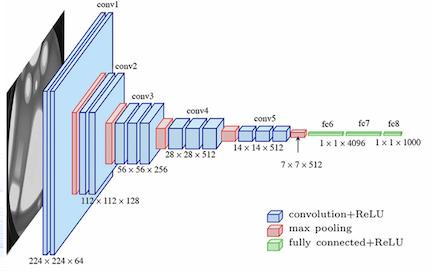


In this exercise you’ll **only vary the learning rate**. Don’t change any other hyperparameters. Your goal is to observe how LR affects convergence speed, stability, and final validation performance compared to your smaller baselines. This sets up next week’s **transfer learning** with pretrained models.

#### Starting point

* Optimizer: **Adam**
* **Recommended LR to start:** `1e-3`(Adam default)

#### What LR values to try (coarse → fine)

Try a short sweep like:

```
[1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
```

Then, as time allows,  zoom in around the best.

#### How to judge “best”

* Primary: **best validation accuracy at epoch of lowest validation loss** 
* Secondary: **time-to-best** (fewer epochs to reach a strong val metric) and **curve shape** (smooth vs. noisy/oscillatory).

#### What symptoms mean

* **LR too high:** training loss spikes or oscillates; val metrics erratic, occasional NaNs/divergence.
* **LR too low:** very slow improvement; long flat regions; never reaches your smaller models’ performance.


**Tip:** Keep LR **constant** during each run (don’t schedule) so you isolate its effect. 




p5--VGG-style Large- lr 1e-3



I0000 00:00:1790717545.777039    2323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1976549__.50
E0000 00:00:1790717546.670020    2323 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790717595.081130    2323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1976549__.50
E0000 00:00:1790717596.824155    2323 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
W0000 00:00:1790717615.784560    2327 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.02GiB (rounded to 3246539264)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current a

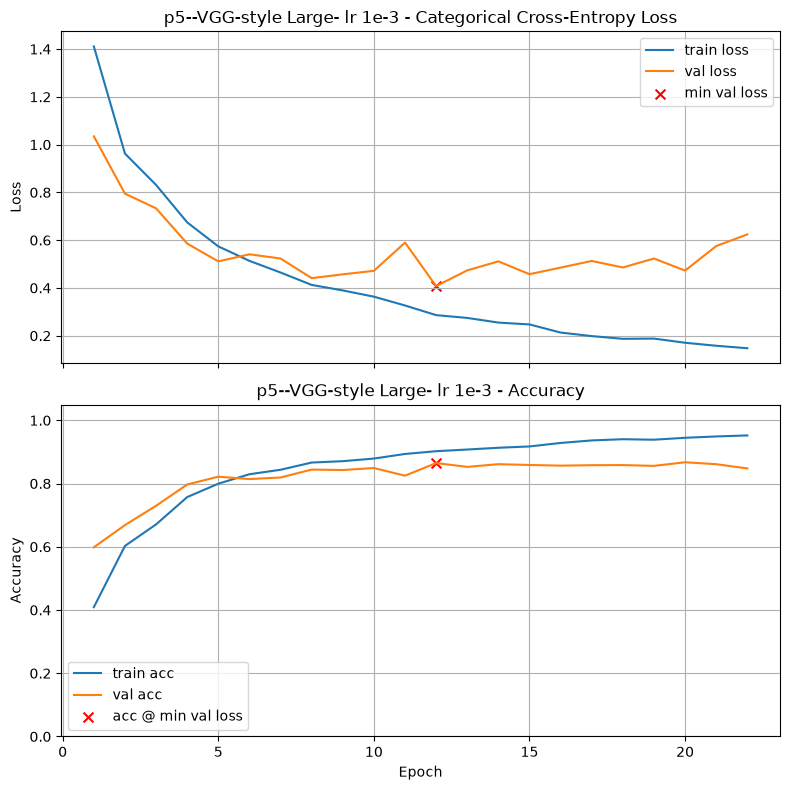

Final Training Loss:            0.1476
Final Training Accuracy:        0.9522
Final Validation Loss:          0.6242
Final Validation Accuracy:      0.8477
Minimum Validation Loss:        0.4076 (Epoch 12)
Validation Accuracy @ Min Loss: 0.8648

Test Loss: 0.4395
Test Accuracy: 0.8563

Validation-Test Gap (accuracy): 0.008503

Execution Time: 00:15:50


In [34]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model1_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model1_vgg_16,lr_schedule=1e-3,title="p5--VGG-style Large- lr 1e-3")



p5--VGG-style Large- lr 1e-2



I0000 00:00:1790718495.748127    2326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2021276__.50
I0000 00:00:1790718536.466258    2326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2021276__.50


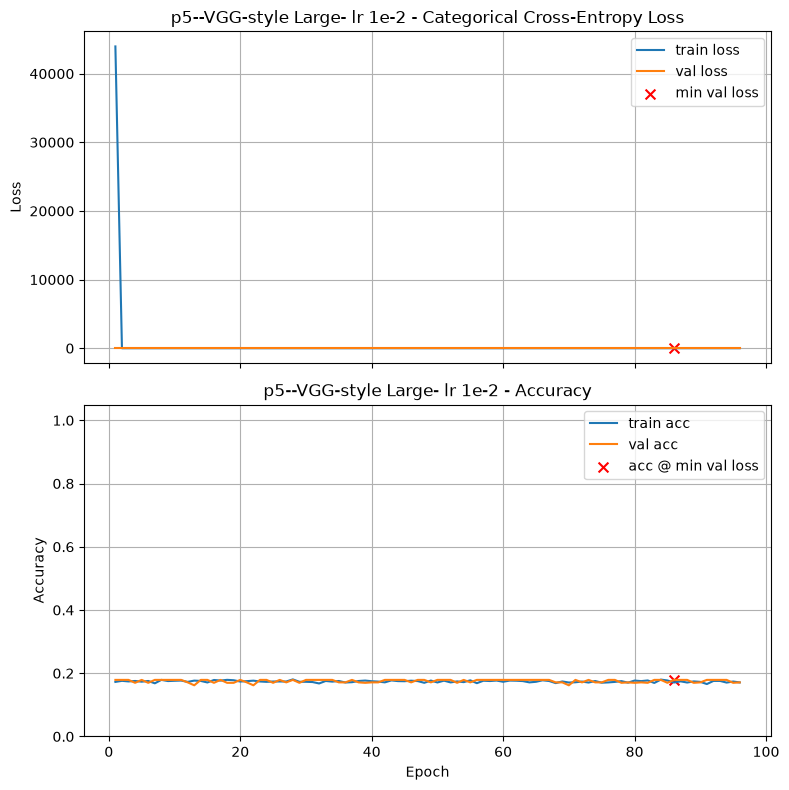

Final Training Loss:            1.7919
Final Training Accuracy:        0.1710
Final Validation Loss:          1.7916
Final Validation Accuracy:      0.1712
Minimum Validation Loss:        1.7909 (Epoch 86)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7907
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 01:05:05


In [35]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model2_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model2_vgg_16,lr_schedule=1e-2,title="p5--VGG-style Large- lr 1e-2")



p5--VGG-style Large- lr 1e-4



I0000 00:00:1790722401.588426    2324 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2199507__.50
I0000 00:00:1790722443.257025    2323 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2199507__.50


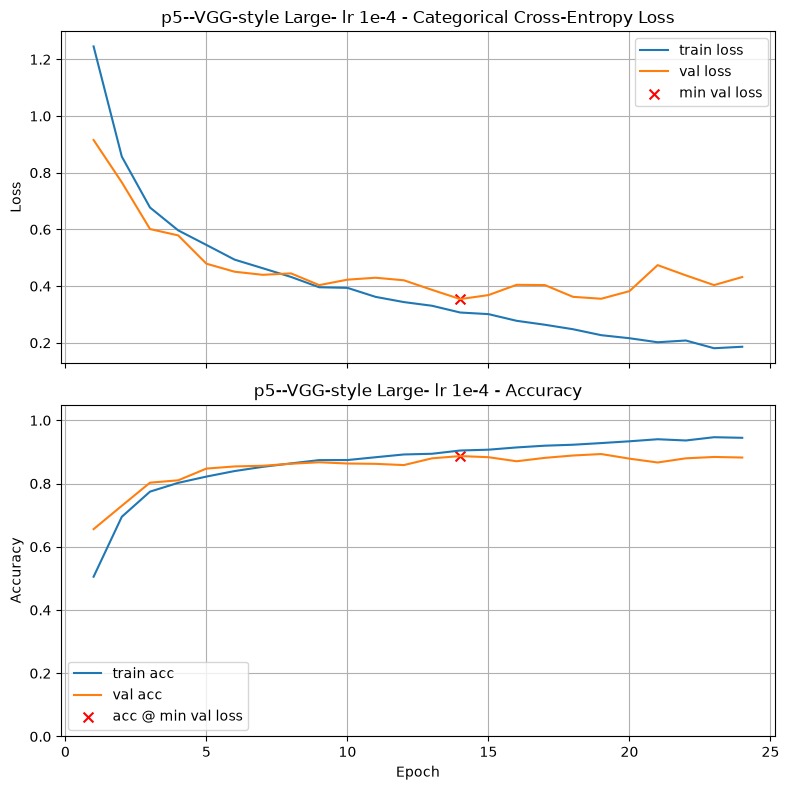

Final Training Loss:            0.1862
Final Training Accuracy:        0.9447
Final Validation Loss:          0.4321
Final Validation Accuracy:      0.8823
Minimum Validation Loss:        0.3543 (Epoch 14)
Validation Accuracy @ Min Loss: 0.8869

Test Loss: 0.3511
Test Accuracy: 0.8887

Validation-Test Gap (accuracy): 0.001719

Execution Time: 00:16:54


In [36]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model3_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model3_vgg_16,lr_schedule=1e-4,title="p5--VGG-style Large- lr 1e-4")


### Graded Questions

In [56]:
# Set a5a to the learning rate which gave the best validation accuracy at the point of minimum validation loss

a5a = 1e-4             # Replace with your best learning rate

In [57]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.8f}') 

a5a = 0.00010000


In [58]:
# Set a5b to the validation accuracy found by the choice specified in Question a5a (your best model for this problem) 

a5b = 0.8869             # Replace 0.0 with your answer           

In [59]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8869


## All Results

This will print out the results from all experiments, with titles as keys. I use this all the time to keep track of experiments!

In [41]:
print_results()

p5--VGG-style Large- lr 1e-4            	0.8869	14
p5--VGG-style Large- lr 1e-3            	0.8648	12
p4-patience: 5                          	0.8324	149
p4-factor: 0.3                          	0.8238	101
p4-factor: 0.5                          	0.8006	168
p4-patience: 3                          	0.7892	62
p4-factor: 0.2                          	0.7882	278
p1--tweak3--conv[64->128]               	0.7842	18
p1--tweak2--conv[64->128]               	0.7835	10
p3-baseline                             	0.7767	14
baseline                                	0.7518	25
p3--tweak2--conv[64->128]               	0.7511	7
Baseline Model                          	0.7464	17
p1--tweak6--do:0.3                      	0.7436	5
p1--tweak4--dense(32)                   	0.6566	21
p2 Model - batch normalization          	0.5631	33
p1--tweak5--l2_reg:1e-4                 	0.1790	28
p5--VGG-style Large- lr 1e-2            	0.1790	86


In [42]:
all_runtime_end = time.time()
print(f"Total all runtime : {format_hms(all_runtime_end - all_runtime_start)}")

Total all runtime : 03:14:32


#note.. all processing with full dataset ran for 3 hour 14 min. 